# TP pratique : Construire un CNN simple avec TensorFlow

## Objectif

Construire un CNN simple de classification d'images, étape par étape :

- charger un dataset d'images ;
- construire un CNN simple ;
- entraîner le modèle ;
- évaluer le modèle ;
- tester le modèle sur une image externe.

### Éléments volontairement exclus

Pour se concentrer sur les fondamentaux, nous n'utilisons pas :

- Data Augmentation ;
- `RandomCrop` ;
- `RandomHorizontalFlip` ;
- `Normalize` ;
- Batch Normalization ;
- Dropout ;
- scheduler ;
- transfer learning ;
- modèle pré-entraîné.

> Dataset : **MNIST**. Ses images font `32 × 32` pixels et possèdent 1 canal (grayscale).

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [2]:
# 1. Load and preprocess the MNIST dataset
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1], add a channel dimension, and resize to 32x32
X_train = tf.image.resize(X_train[..., tf.newaxis], (32, 32)) / 255.0
X_test = tf.image.resize(X_test[..., tf.newaxis], (32, 32)) / 255.0

In [3]:
import numpy as np

# Get the unique labels from y_train
labels = np.unique(y_train)
print("Classes :", labels)

Classes : [0 1 2 3 4 5 6 7 8 9]


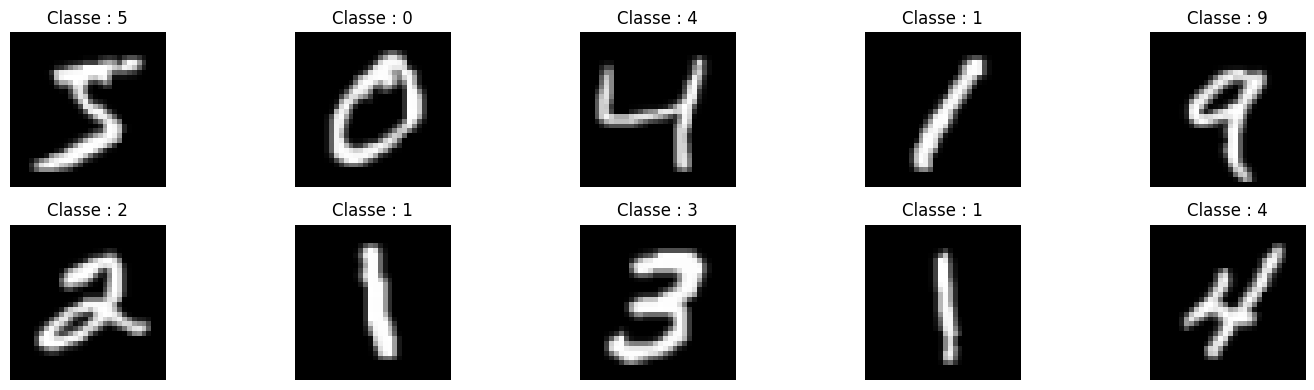

In [4]:
# Afficher plusieurs images du dataset d'entraînement
nombre_images = 10

plt.figure(figsize=(15, 4))

for i in range(nombre_images):
    image = X_train[i]
    label = int(y_train[i])

    plt.subplot(2, 5, i + 1)
    plt.imshow(tf.squeeze(image), cmap="gray")
    plt.title(f"Classe : {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# 2. Build the CNN model
model = models.Sequential([
    # Input layer 
    # H, W, C
    Input(shape=(32, 32, 1)),

    # First Convolutional Block
    # Create 32 feature maps using 3x3 filters, followed by a ReLU activation and 2x2 max pooling
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    # Create 64 feature maps using 3x3 filters, followed by a ReLU activation and 2x2 max pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Classifier
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model

<Sequential name=sequential, built=True>

In [6]:
# 3. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Configure Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [7]:
# 4. Train the model
model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9469 - loss: 0.1793 - val_accuracy: 0.9762 - val_loss: 0.0727
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9825 - loss: 0.0550 - val_accuracy: 0.9846 - val_loss: 0.0450
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9884 - loss: 0.0381 - val_accuracy: 0.9881 - val_loss: 0.0370
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9907 - loss: 0.0297 - val_accuracy: 0.9876 - val_loss: 0.0367
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9924 - loss: 0.0235 - val_accuracy: 0.9900 - val_loss: 0.0310


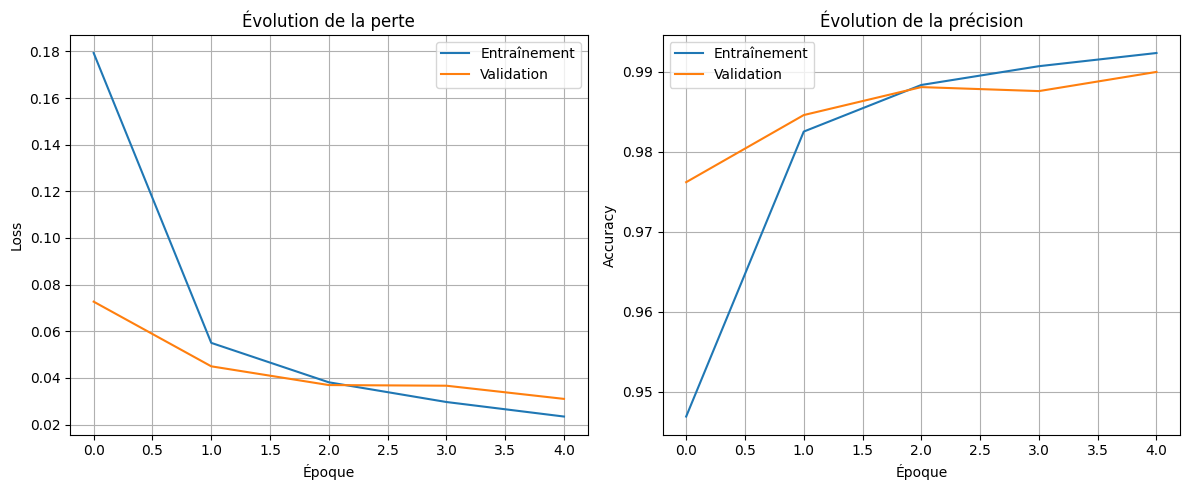

In [8]:
# 5. Tracer l'historique de l'entraînement
history = model.history.history

plt.figure(figsize=(12, 5))

# Courbes de perte
plt.subplot(1, 2, 1)
plt.plot(history["loss"], label="Entraînement")
plt.plot(history["val_loss"], label="Validation")
plt.title("Évolution de la perte")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Courbes de précision
plt.subplot(1, 2, 2)
plt.plot(history["accuracy"], label="Entraînement")
plt.plot(history["val_accuracy"], label="Validation")
plt.title("Évolution de la précision")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
# 5. Evaluate final performance
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")


Test Accuracy: 99.02%


# Réaliser par : OUARAS Khelil Rafik 